In [9]:
import random
import matplotlib.pyplot as plt

In [10]:
random.seed(42)

x = list(range(1, 46))
y = [2 * xi + 3 + random.randint(-10, 10) for xi in x]

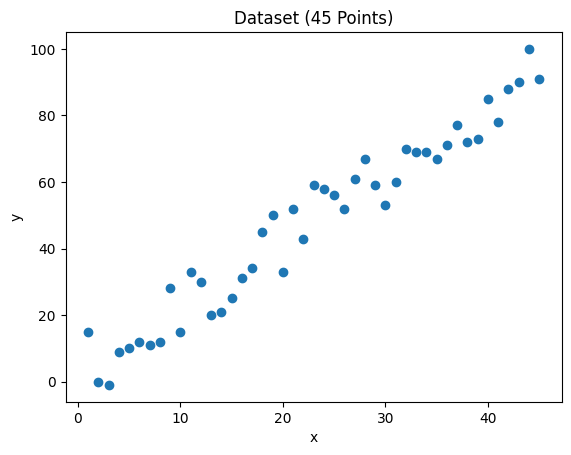

In [11]:
plt.figure()
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset (45 Points)")
plt.show()

Brute Force Linear Regression

In [12]:
best_m = 0
best_b = 0
min_error = float('inf')

for m in [i * 0.1 for i in range(0, 50)]:
    for b in [i * 0.1 for i in range(0, 50)]:
        error = 0
        for i in range(len(x)):
            y_pred = m * x[i] + b
            error += (y[i] - y_pred) ** 2
        
        error /= len(x)
        
        if error < min_error:
            min_error = error
            best_m = m
            best_b = b

print("Brute Force m:", best_m)
print("Brute Force b:", best_b)
print("Brute Force MSE:", min_error)


Brute Force m: 2.0
Brute Force b: 1.8
Brute Force MSE: 38.40000000000001


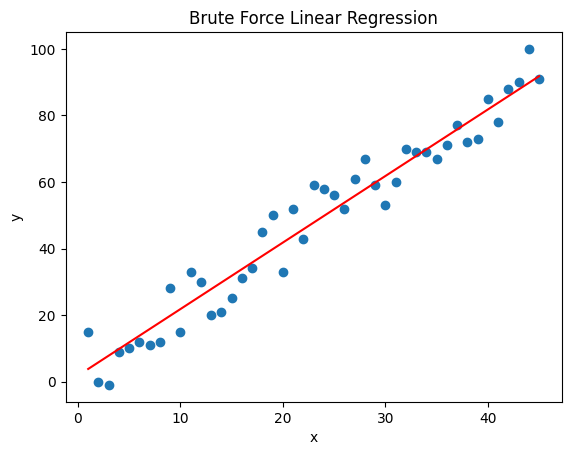

In [15]:
y_brute = [best_m * xi + best_b for xi in x]

plt.figure()
plt.scatter(x, y)
plt.plot(x, y_brute, c='r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Brute Force Linear Regression")
plt.show()


Gradient Descent Implementation

In [16]:
m = 0
b = 0
learning_rate = 0.0005
epochs = 1000
n = len(x)

losses = []

for _ in range(epochs):
    dm = 0
    db = 0
    loss = 0

    for i in range(n):
        y_pred = m * x[i] + b
        error = y[i] - y_pred
        
        loss += error ** 2
        dm += -2 * x[i] * error
        db += -2 * error

    loss /= n          # Mean Squared Error
    losses.append(loss)

    dm /= n
    db /= n

    m -= learning_rate * dm
    b -= learning_rate * db

print("Gradient Descent m:", m)
print("Gradient Descent b:", b)
print("Gradient Descent Final MSE:", losses[-1])


Gradient Descent m: 2.0603898139364722
Gradient Descent b: 0.27375022419522643
Gradient Descent Final MSE: 38.32155378181924


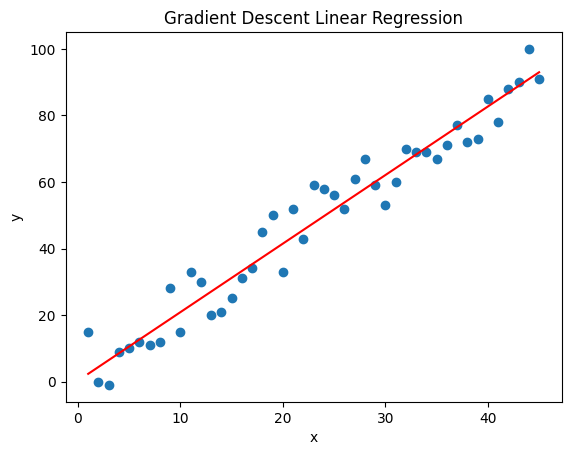

In [17]:
y_gd = [m * xi + b for xi in x]

plt.figure()
plt.scatter(x, y)
plt.plot(x, y_gd,c='r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent Linear Regression")
plt.show()


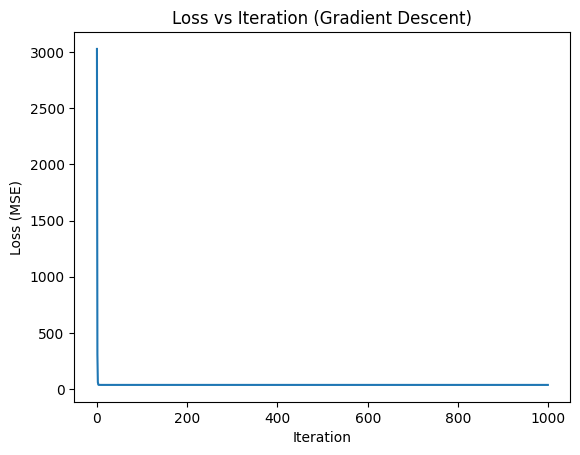

In [18]:
plt.figure()
plt.plot(range(epochs), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iteration (Gradient Descent)")
plt.show()
